In [1]:
import numpy as np 
import os 
import xarray as xr
import pandas as pd
#from scipy.io import savemat
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib as mpl
from matplotlib import colors
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.pyplot import cm
import matplotlib

import mplcursors

In [3]:
#load file for all dates
all_days_filepath = '../../CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)

In [ ]:
df_july_dates_only = df_alldays.sort_index().loc["2024-07-14 18:00:00":"2024-07-31 23:30:00"]
df_august_dates_only = df_alldays.sort_index().loc["2024-08-01":"2024-08-18 17:30:00"]

#add july and august ozone species to df
df_july_species = pd.DataFrame()
df_august_species = pd.DataFrame()

df_july_species['O3'] = df_july_dates_only['O3_ppbv'].to_frame()
df_august_species['O3']= df_august_dates_only['O3_ppbv'].to_frame()

halogens_varlist = ['Br2_CIMS', 'BrO_CIMS', 'Cl2_CIMS', 'ClNO2_CIMS', 'BrCl_CIMS']
halogens_species_list = ['Br2', 'BrO', 'Cl2', 'ClNO2', 'BrCl']

#add july and august halogen species to df
for hal_species in range(0,5):
    df_july_species[halogens_species_list[hal_species]] = df_july_dates_only[halogens_varlist[hal_species]].to_frame()
    df_august_species[halogens_species_list[hal_species]] = df_august_dates_only[halogens_varlist[hal_species]].to_frame()

,O3,Br2,BrO,Cl2,ClNO2,BrCl
time_local,,,,,,
2024-07-14 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-14 18:30:00,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-14 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-14 19:30:00,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-14 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-07-31 21:30:00,50.557889,0.000604,0.000108,0.001226,0.000183,0.000294
2024-07-31 22:00:00,50.708222,0.000543,0.000134,0.001144,0.000192,0.000272
2024-07-31 22:30:00,49.407444,0.000552,0.000134,0.001144,0.000215,0.000269


In [60]:
#7/16, 7/17, 7/23, 7/24, 7/26, 7/30, 7/31, 8/01, 8/02, 8/08

july_dates = pd.date_range(start='2024-07-14', end='2024-07-31')
july_dates_list = july_dates.strftime('%Y-%m-%d')
august_dates = pd.date_range(start='2024-08-01', end='2024-08-19')
august_dates_list = august_dates.strftime('%Y-%m-%d')

july_exceedances_start = [july_dates[2], july_dates[3], july_dates[9], july_dates[10], july_dates[12], july_dates[16], july_dates[17]]
july_exceedances_end = [july_dates[3], july_dates[4], july_dates[10], july_dates[11], july_dates[13], july_dates[17], df_july_dates_only.index[827]]

august_exceedances_start = [august_dates[0], august_dates[1], august_dates[7]]
august_exceedances_end = [august_dates[1], august_dates[2], august_dates[8]]

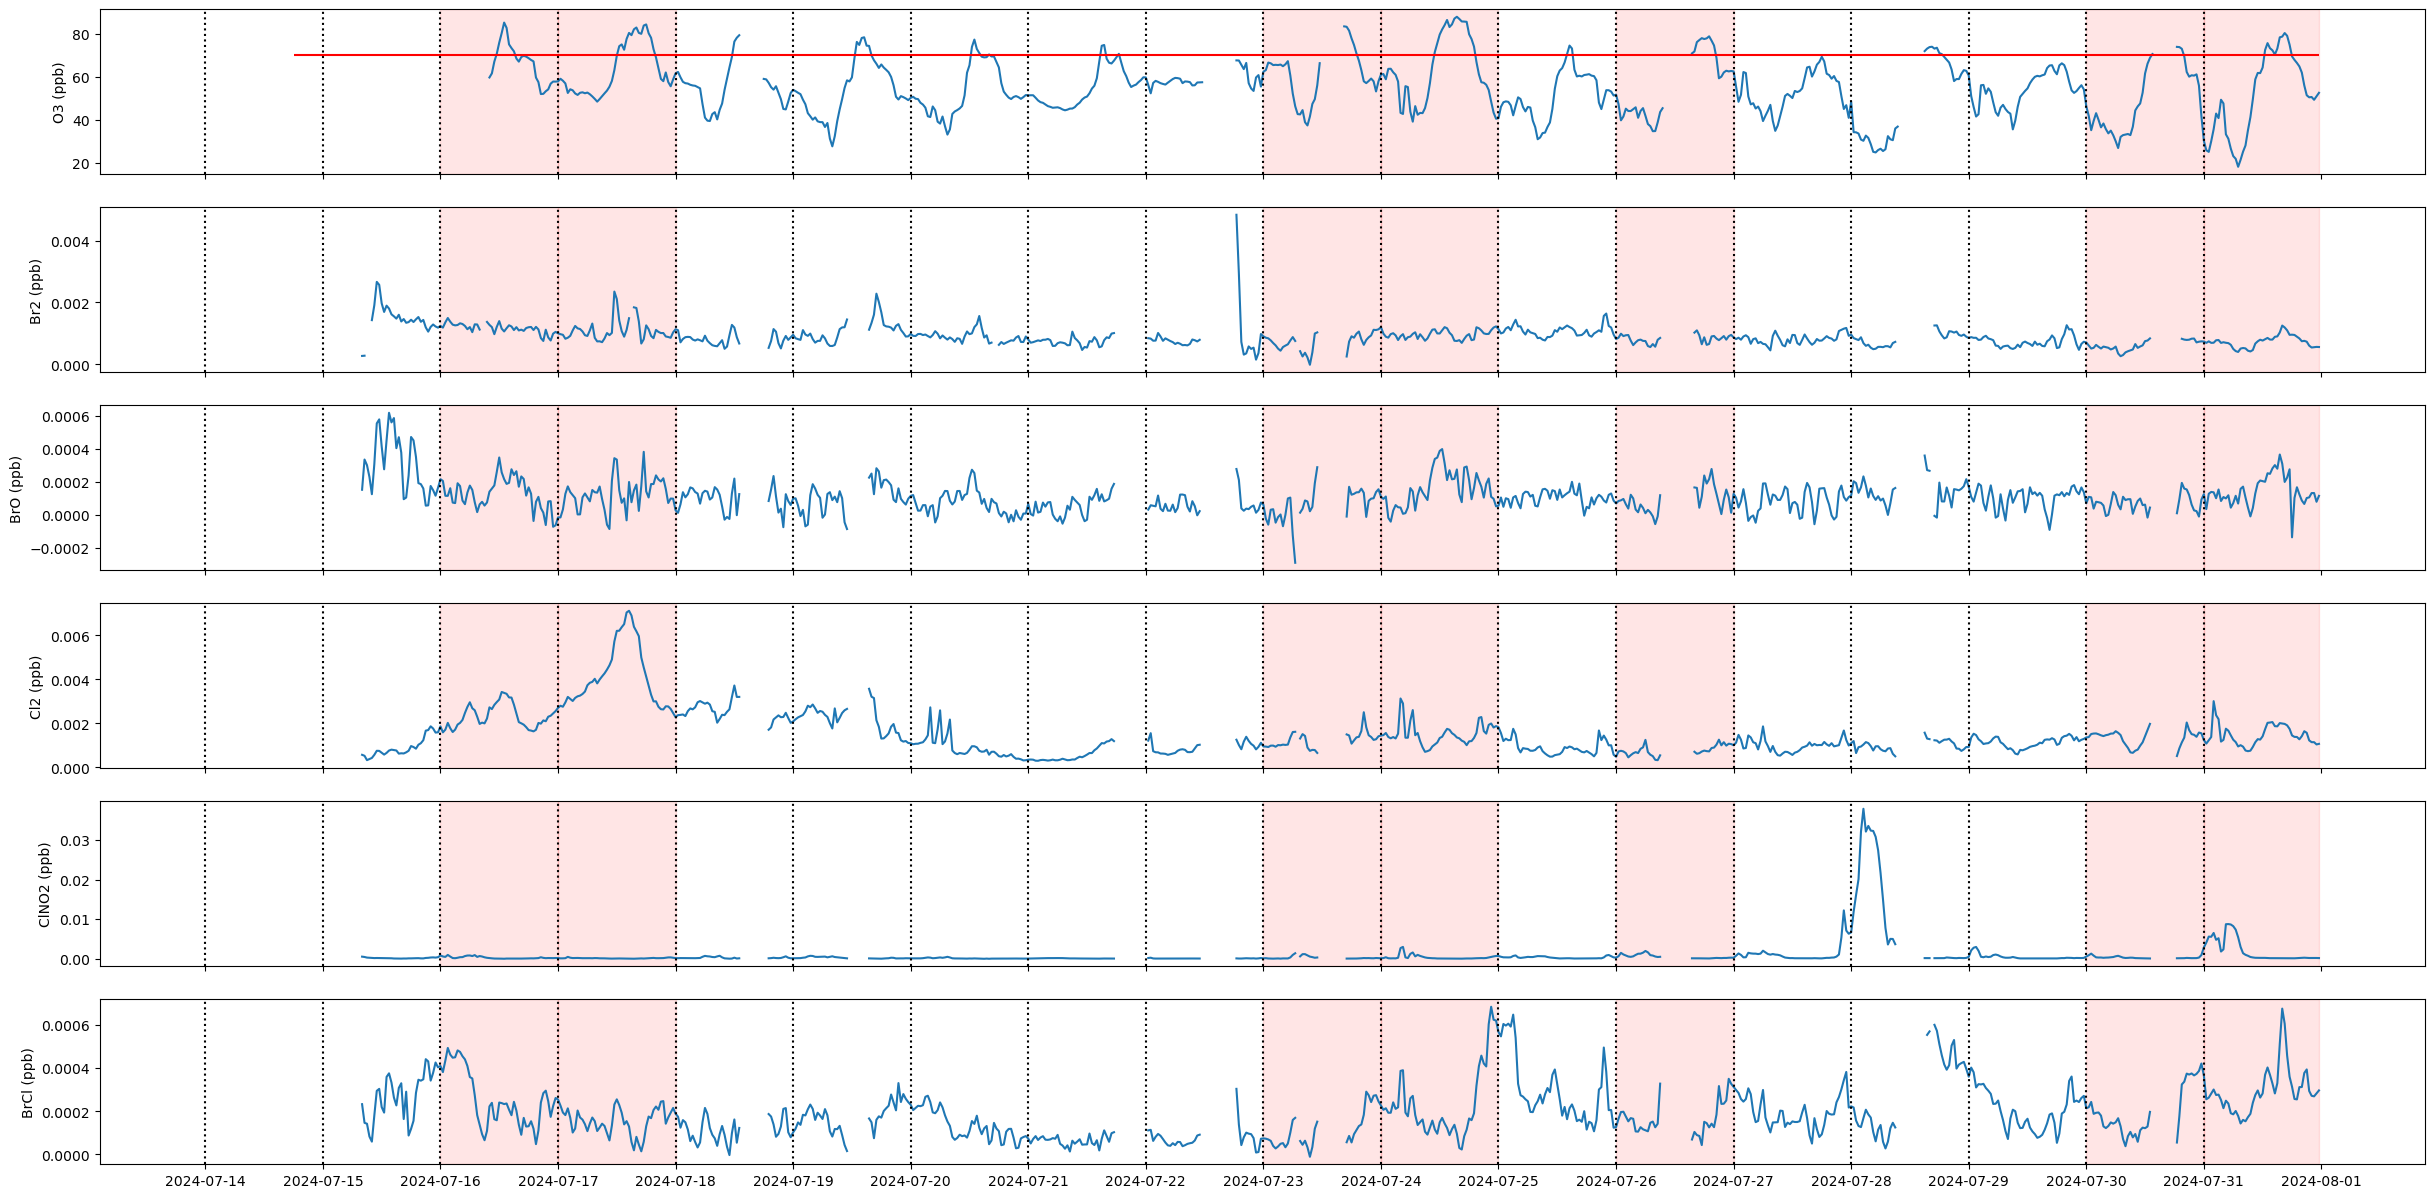

In [58]:
fig, axs = plt.subplots(6, figsize = (30,15), sharex=True)

for spec in range(0,6):
    axs[spec].plot(df_july_dates_only.index, df_july_species[df_july_species.columns[spec]],label=df_july_species.columns[spec])
    axs[spec].set_ylabel(df_july_species.columns[spec] + ' (ppb)')

    #Format ticks
    axs[spec].xaxis.set_major_locator(mdates.DayLocator())
    axs[spec].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    for midnight in july_dates:
        axs[spec].axvline(midnight, color = 'black', linestyle = 'dotted')
    for exceedances in range(0,7):
        axs[spec].axvspan(july_exceedances_start[exceedances], july_exceedances_end[exceedances], color='red', alpha=0.1)

axs[0].hlines(y=70, xmin =df_july_dates_only.index[0], xmax = df_july_dates_only.index[len(df_july_dates_only)-1], color = 'r')


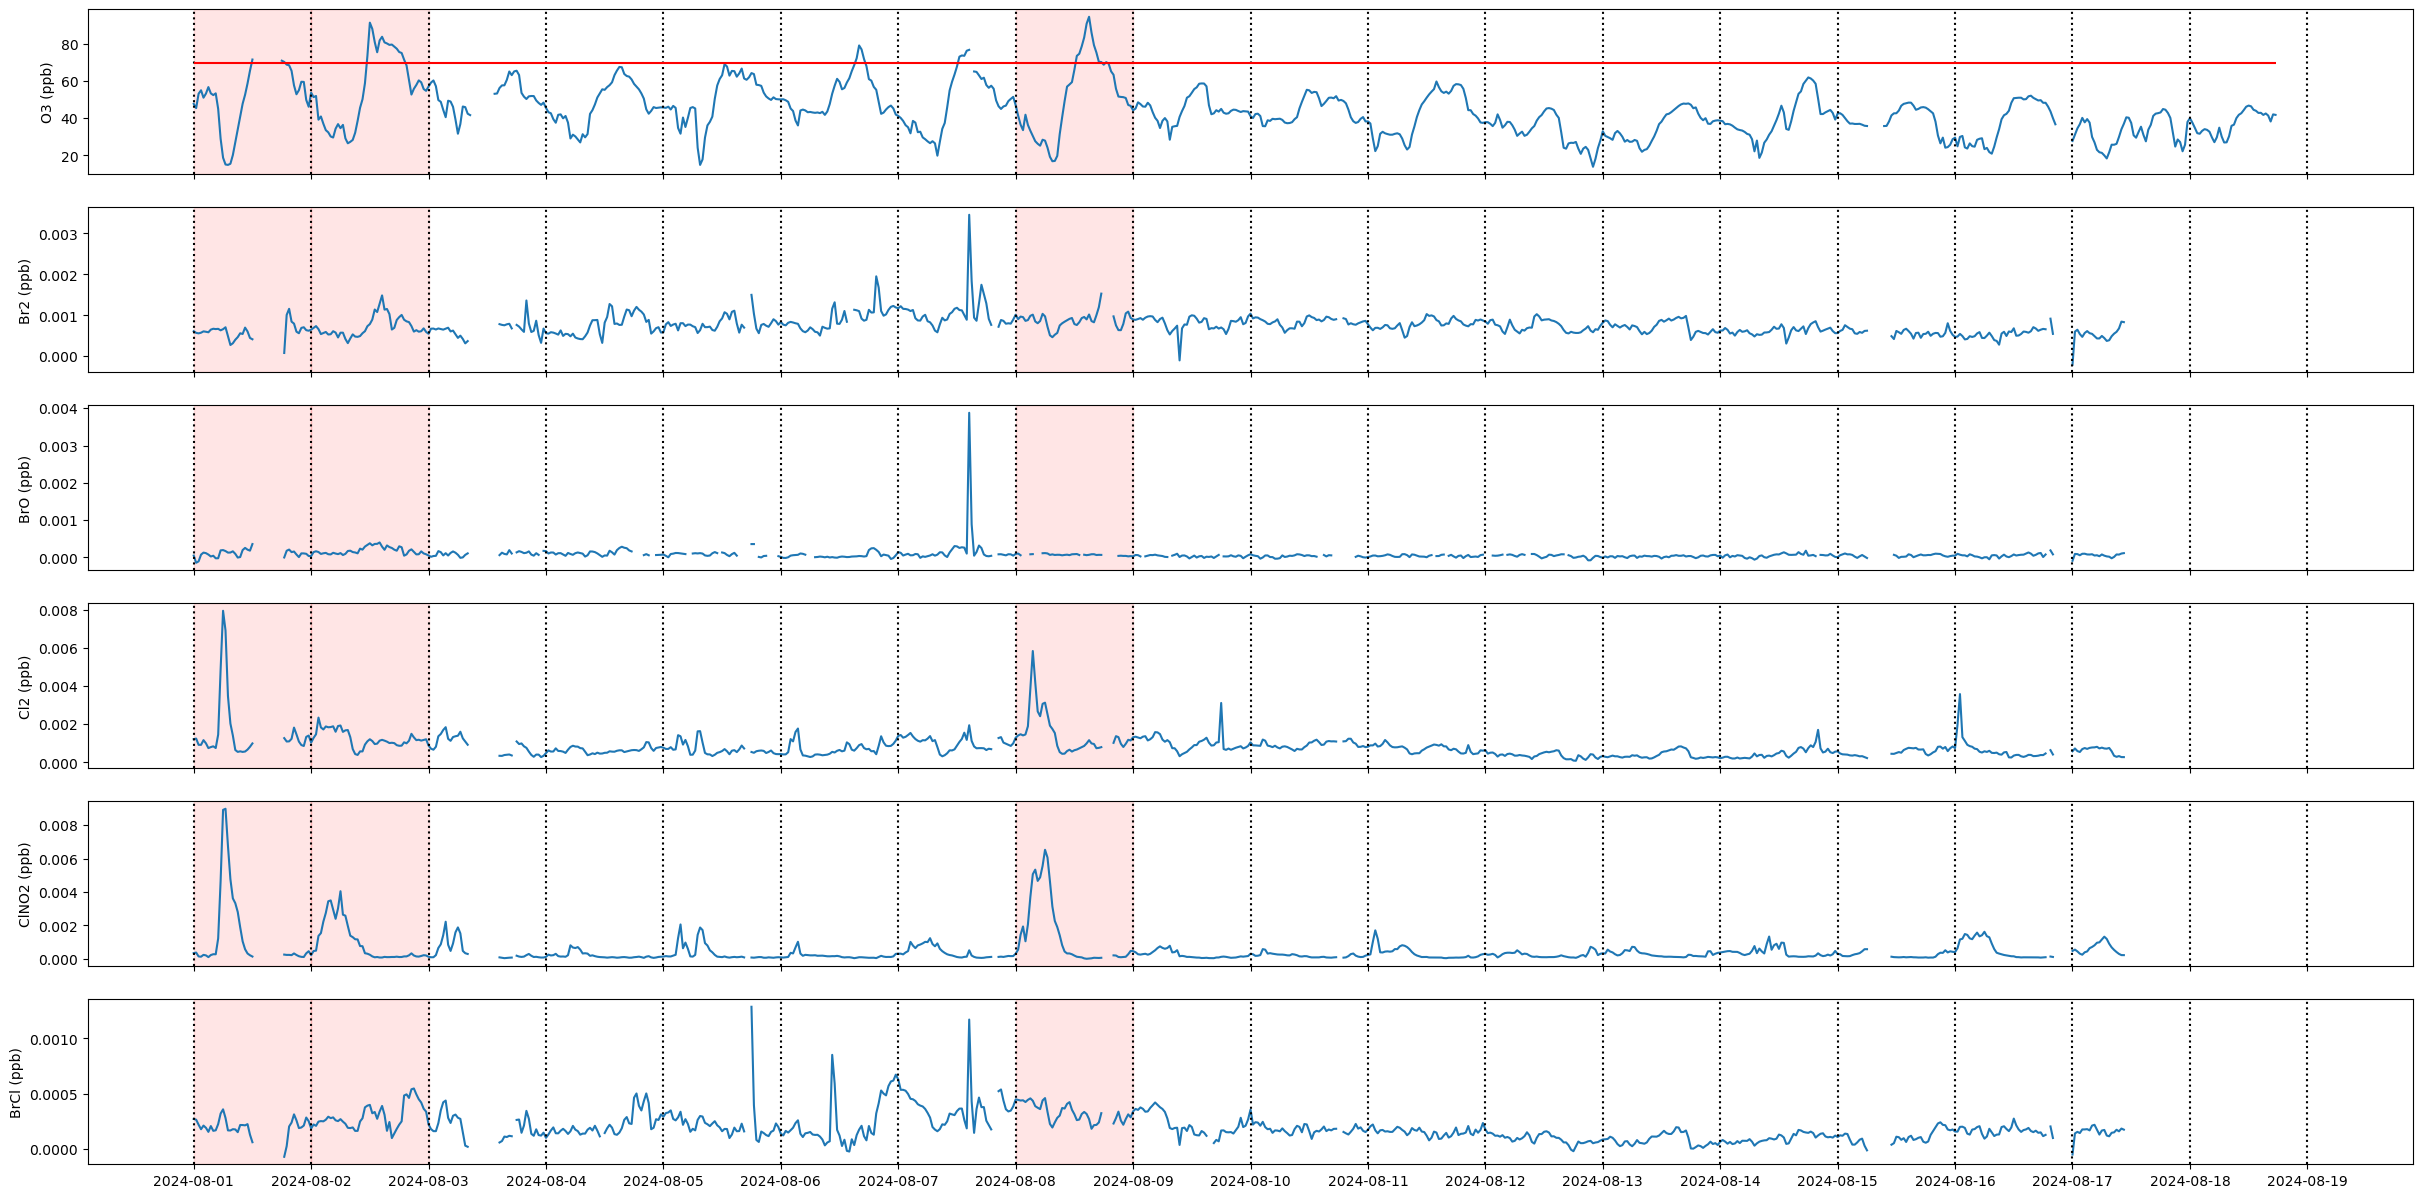

In [61]:
fig, axs = plt.subplots(6, figsize = (30,15), sharex=True)

for spec in range(0,6):
    axs[spec].plot(df_august_dates_only.index, df_august_species[df_august_species.columns[spec]],label=df_august_species.columns[spec])
    axs[spec].set_ylabel(df_august_species.columns[spec] + ' (ppb)')

    #Format ticks
    axs[spec].xaxis.set_major_locator(mdates.DayLocator())
    axs[spec].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    for midnight in august_dates:
        axs[spec].axvline(midnight, color = 'black', linestyle = 'dotted')
    for exceedances in range(0,3):
        axs[spec].axvspan(august_exceedances_start[exceedances], august_exceedances_end[exceedances], color='red', alpha=0.1)

axs[0].hlines(y=70, xmin =df_august_dates_only.index[0], xmax = df_august_dates_only.index[len(df_august_dates_only)-1], color = 'r')